In [1]:
!nvidia-smi

Tue Jul 14 02:15:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import triton
import triton.language as tl

x = torch.rand(98432, device="cuda")
y = torch.rand(98432, device="cuda")

In [3]:
@triton.jit
def add_kernel(x_ptr, y_ptr, out_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    tl.store(out_ptr + offsets, x + y, mask=mask)

def add(x, y):
    out = torch.empty_like(x)
    n = x.numel()
    grid = (triton.cdiv(n, 1024),)
    add_kernel[grid](x, y, out, n, BLOCK_SIZE=1024)
    return out

out = add(x, y)
print(torch.allclose(out, x + y))

True


In [4]:
x = torch.randn(1823, 781, device="cuda")
ref = torch.softmax(x, dim=1)

In [5]:
@triton.jit
def softmax_kernel(x_ptr, out_ptr, stride, n_cols, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    row_start = x_ptr + pid * stride
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_cols
    row = tl.load(row_start + offsets, mask=mask, other=float('-inf'))
    row_max = tl.max(row, axis=0)
    numerator = tl.exp(row - row_max)
    denominator = tl.sum(numerator, axis=0)
    result = numerator / denominator
    out_row_start = out_ptr + pid * stride
    tl.store(out_row_start + offsets, result, mask=mask)

def softmax(x):
    n_rows, n_cols = x.shape
    out = torch.empty_like(x)
    BLOCK_SIZE = triton.next_power_of_2(n_cols)
    softmax_kernel[(n_rows,)](x, out, x.stride(0), n_cols, BLOCK_SIZE=BLOCK_SIZE)
    return out

out = softmax(x)
print(torch.allclose(out, ref, atol=1e-6))

for shape in [(128, 128), (500, 781), (32, 4096), (2048, 1000)]:
    t = torch.randn(*shape, device="cuda")
    assert torch.allclose(softmax(t), torch.softmax(t, dim=1), atol=1e-6), shape
print("all shapes pass")

True
all shapes pass


In [6]:
@triton.jit
def rmsnorm_kernel(x_ptr, w_ptr, out_ptr, stride, n_cols, eps, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(axis=0)
    row_start = x_ptr + pid * stride
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_cols
    row = tl.load(row_start + offsets, mask=mask, other=0.0)
    mean_sq = tl.sum(row * row, axis=0) / n_cols
    rstd = 1.0 / tl.sqrt(mean_sq + eps)
    w = tl.load(w_ptr + offsets, mask=mask, other=0.0)
    result = row * rstd * w
    tl.store(out_ptr + pid * stride + offsets, result, mask=mask)

def rmsnorm_ref(x, w, eps=1e-6):
    return x * torch.rsqrt(x.pow(2).mean(dim=1, keepdim=True) + eps) * w

def rmsnorm(x, w, eps=1e-6):
    n_rows, n_cols = x.shape
    out = torch.empty_like(x)
    BLOCK_SIZE = triton.next_power_of_2(n_cols)
    rmsnorm_kernel[(n_rows,)](x, w, out, x.stride(0), n_cols, eps, BLOCK_SIZE=BLOCK_SIZE)
    return out

for shape in [(128, 128), (500, 781), (32, 4096), (2048, 1000)]:
    t = torch.randn(*shape, device="cuda")
    w = torch.randn(shape[1], device="cuda")
    assert torch.allclose(rmsnorm(t, w), rmsnorm_ref(t, w), atol=1e-5), shape
print("all shapes pass")

all shapes pass


In [7]:
M, K, N = 517, 389, 731
a = torch.randn(M, K, device="cuda")
b = torch.randn(K, N, device="cuda")
ref = a @ b

In [8]:
@triton.jit
def gemm_kernel(a_ptr, b_ptr, c_ptr,
                M, N, K,
                stride_am, stride_ak,
                stride_bk, stride_bn,
                stride_cm, stride_cn,
                BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr):
    pid_m = tl.program_id(axis=0)
    pid_n = tl.program_id(axis=1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    a_ptrs = a_ptr + offs_m[:, None] * stride_am + offs_k[None, :] * stride_ak
    b_ptrs = b_ptr + offs_k[:, None] * stride_bk + offs_n[None, :] * stride_bn


    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    for k in range(0, K, BLOCK_K):
        a_mask = (offs_m[:, None] < M) & ((offs_k[None, :] + k) < K)
        b_mask = ((offs_k[:, None] + k) < K) & (offs_n[None, :] < N)
        a_tile = tl.load(a_ptrs, mask=a_mask, other=0.0)
        b_tile = tl.load(b_ptrs, mask=b_mask, other=0.0)
        acc = tl.dot(a_tile, b_tile, acc)
        a_ptrs += BLOCK_K * stride_ak
        b_ptrs += BLOCK_K * stride_bk

    c_ptrs = c_ptr + offs_m[:, None] * stride_cm + offs_n[None, :] * stride_cn
    c_mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(c_ptrs, acc.to(c_ptr.dtype.element_ty), mask=c_mask)

In [9]:
def gemm(a, b):
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    BLOCK_M, BLOCK_N, BLOCK_K = 64, 64, 32
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    gemm_kernel[grid](a, b, c,
                      M, N, K,
                      a.stride(0), a.stride(1),
                      b.stride(0), b.stride(1),
                      c.stride(0), c.stride(1),
                      BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K)
    return c

out = gemm(a, b)
print(torch.allclose(out, ref, atol=1e-3, rtol=1e-3))

for (m, k, n) in [(128, 128, 128), (517, 389, 731), (1024, 1024, 1024), (100, 2000, 300)]:
    ta = torch.randn(m, k, device="cuda")
    tb = torch.randn(k, n, device="cuda")
    assert torch.allclose(gemm(ta, tb), ta @ tb, atol=1e-2, rtol=1e-3), (m, k, n)
print("all shapes pass")

True
all shapes pass


In [10]:
import triton.testing

def bench(fn, warmup=25, rep=100):
    ms = triton.testing.do_bench(fn, warmup=warmup, rep=rep)
    return ms

n = 4096
x = torch.randn(n, n, device="cuda")
w = torch.randn(n, device="cuda")
a4 = torch.randn(n, n, device="cuda")
b4 = torch.randn(n, n, device="cuda")

print("softmax  triton:", bench(lambda: softmax(x)), "ms")
print("softmax  torch :", bench(lambda: torch.softmax(x, dim=1)), "ms")
print("rmsnorm  triton:", bench(lambda: rmsnorm(x, w)), "ms")
print("rmsnorm  torch :", bench(lambda: rmsnorm_ref(x, w)), "ms")
print("gemm     triton:", bench(lambda: gemm(a4, b4)), "ms")
print("gemm     torch :", bench(lambda: a4 @ b4), "ms")

softmax  triton: 0.5727435245233423 ms
softmax  torch : 0.8893259974817435 ms
rmsnorm  triton: 0.5882436486712673 ms
rmsnorm  torch : 1.9637770460497948 ms
gemm     triton: 51.98422431945801 ms
gemm     torch : 57.470895767211914 ms


In [11]:
import csv, math

def gflops_gemm(n, ms):
    return 2 * n**3 / (ms * 1e-3) / 1e9

def gbps_rowwise(n_rows, n_cols, ms, bytes_per_el=4):
    total_bytes = 2 * n_rows * n_cols * bytes_per_el   # one read + one write
    return total_bytes / (ms * 1e-3) / 1e9

sizes = [256, 512, 1024, 2048, 4096, 8192]
rows = []

for n in sizes:
    x = torch.randn(n, n, device="cuda")
    w = torch.randn(n, device="cuda")
    rows.append(("softmax", "triton", n, bench(lambda: softmax(x))))
    rows.append(("softmax", "torch",  n, bench(lambda: torch.softmax(x, dim=1))))
    rows.append(("rmsnorm", "triton", n, bench(lambda: rmsnorm(x, w))))
    rows.append(("rmsnorm", "torch",  n, bench(lambda: rmsnorm_ref(x, w))))
    a_ = torch.randn(n, n, device="cuda")
    b_ = torch.randn(n, n, device="cuda")
    rows.append(("gemm", "triton", n, bench(lambda: gemm(a_, b_))))
    rows.append(("gemm", "torch",  n, bench(lambda: a_ @ b_)))
    del x, w, a_, b_
    torch.cuda.empty_cache()

with open("results_t4_fp32.csv", "w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["kernel", "impl", "size", "ms"])
    wr.writerows(rows)

print(f"{len(rows)} rows written")
for r in rows[-6:]:
    print(r)

36 rows written
('softmax', 'triton', 8192, 2.3331291505268643)
('softmax', 'torch', 8192, 2.149046067533822)
('rmsnorm', 'triton', 8192, 2.335813726697649)
('rmsnorm', 'torch', 8192, 7.708674951033159)
('gemm', 'triton', 8192, 485.1112060546875)
('gemm', 'torch', 8192, 325.7586669921875)


In [12]:
rows16 = []
for n in sizes:
    x = torch.randn(n, n, device="cuda", dtype=torch.float16)
    w = torch.randn(n, device="cuda", dtype=torch.float16)
    rows16.append(("softmax", "triton", n, bench(lambda: softmax(x))))
    rows16.append(("softmax", "torch",  n, bench(lambda: torch.softmax(x, dim=1))))
    rows16.append(("rmsnorm", "triton", n, bench(lambda: rmsnorm(x, w))))
    rows16.append(("rmsnorm", "torch",  n, bench(lambda: rmsnorm_ref(x, w))))
    a_ = torch.randn(n, n, device="cuda", dtype=torch.float16)
    b_ = torch.randn(n, n, device="cuda", dtype=torch.float16)
    rows16.append(("gemm", "triton", n, bench(lambda: gemm(a_, b_))))
    rows16.append(("gemm", "torch",  n, bench(lambda: a_ @ b_)))
    del x, w, a_, b_
    torch.cuda.empty_cache()

with open("results_t4_fp16.csv", "w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["kernel", "impl", "size", "ms"])
    wr.writerows(rows16)

print(f"{len(rows16)} rows written")
for r in rows16[-6:]:
    print(r)

36 rows written
('softmax', 'triton', 8192, 1.1544335285822551)
('softmax', 'torch', 8192, 1.8561027395097833)
('rmsnorm', 'triton', 8192, 1.1776053394590105)
('rmsnorm', 'torch', 8192, 4.76348270310296)
('gemm', 'triton', 8192, 1135.8204345703125)
('gemm', 'torch', 8192, 55.46198272705078)


In [13]:
import itertools

n = 4096
a_ = torch.randn(n, n, device="cuda", dtype=torch.float16)
b_ = torch.randn(n, n, device="cuda", dtype=torch.float16)
ref_ = a_ @ b_

def gemm_cfg(a, b, BM, BN, BK, warps, stages):
    M, K = a.shape
    _, N = b.shape
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    grid = (triton.cdiv(M, BM), triton.cdiv(N, BN))
    gemm_kernel[grid](a, b, c, M, N, K,
                      a.stride(0), a.stride(1),
                      b.stride(0), b.stride(1),
                      c.stride(0), c.stride(1),
                      BLOCK_M=BM, BLOCK_N=BN, BLOCK_K=BK,
                      num_warps=warps, num_stages=stages)
    return c

configs = list(itertools.product([64, 128], [64, 128], [32, 64], [4, 8], [2, 3]))
results = []
for BM, BN, BK, w, s in configs:
    try:
        ok = torch.allclose(gemm_cfg(a_, b_, BM, BN, BK, w, s).float(), ref_.float(), atol=1e-1, rtol=1e-2)
        ms = bench(lambda: gemm_cfg(a_, b_, BM, BN, BK, w, s))
        results.append((ms, BM, BN, BK, w, s, ok))
    except Exception as e:
        results.append((float('inf'), BM, BN, BK, w, s, str(e)[:40]))

results.sort()
print(f"{'ms':>10}  BM  BN  BK  warps stages ok")
for ms, BM, BN, BK, w, s, ok in results[:8]:
    print(f"{ms:10.2f}  {BM:3} {BN:3} {BK:3}  {w:5} {s:6} {ok}")
print("torch:", bench(lambda: a_ @ b_), "ms")

        ms  BM  BN  BK  warps stages ok
     59.06   64  64  32      8      2 True
     59.11   64  64  32      8      3 True
     80.63   64  64  64      8      3 True
     80.71   64  64  64      8      2 True
    124.68   64 128  32      8      2 True
    124.79   64 128  32      8      3 True
    130.26  128  64  32      8      2 True
    130.61  128  64  32      8      3 True
torch: 7.434174581007524 ms


In [17]:
for BM, BN, BK, w, s in [(64, 64, 32, 8, 2), (64, 64, 32, 8, 3), (64, 64, 64, 8, 3), (128, 64, 32, 8, 2), (128, 128, 32, 8, 3)]:
    ok = torch.allclose(gemm_cfg(a_, b_, BM, BN, BK, w, s).float(), ref_.float(), atol=1e-1, rtol=1e-2)
    ms = bench(lambda: gemm_cfg(a_, b_, BM, BN, BK, w, s))
    print(f"{ms:8.2f} ms  {BM}/{BN}/{BK} w={w} s={s} correct={ok}")
print("torch:", bench(lambda: a_ @ b_), "ms")

   59.18 ms  64/64/32 w=8 s=2 correct=True
   59.76 ms  64/64/32 w=8 s=3 correct=True
   84.35 ms  64/64/64 w=8 s=3 correct=True
  123.94 ms  128/64/32 w=8 s=2 correct=True
 1684.70 ms  128/128/32 w=8 s=3 correct=True
torch: 8.317056020100912 ms


In [18]:
c_tmp = torch.empty(n, n, device="cuda", dtype=torch.float16)
compiled = gemm_kernel.warmup(
    a_, b_, c_tmp, n, n, n,
    a_.stride(0), a_.stride(1),
    b_.stride(0), b_.stride(1),
    c_tmp.stride(0), c_tmp.stride(1),
    BLOCK_M=64, BLOCK_N=64, BLOCK_K=32,
    num_warps=8, num_stages=2,
    grid=(1,),
)
ptx = compiled.asm["ptx"]
print("mma.sync count:", ptx.count("mma.sync"))
print("fma count     :", ptx.count("fma"))
print("cvt f16 count :", ptx.count("cvt"))

mma.sync count: 0
fma count     : 512
cvt f16 count : 34


In [19]:
print("compute capability:", torch.cuda.get_device_capability())

@triton.jit
def tiny_dot(a_ptr, b_ptr, c_ptr, BLOCK: tl.constexpr):
    offs = tl.arange(0, BLOCK)
    a = tl.load(a_ptr + offs[:, None] * BLOCK + offs[None, :])
    b = tl.load(b_ptr + offs[:, None] * BLOCK + offs[None, :])
    c = tl.dot(a, b)
    tl.store(c_ptr + offs[:, None] * BLOCK + offs[None, :], c)

ta = torch.randn(64, 64, device="cuda", dtype=torch.float16)
tb = torch.randn(64, 64, device="cuda", dtype=torch.float16)
tc = torch.empty(64, 64, device="cuda", dtype=torch.float32)

compiled_tiny = tiny_dot.warmup(ta, tb, tc, BLOCK=64, grid=(1,))
ptx2 = compiled_tiny.asm["ptx"]
print("tiny  mma count:", ptx2.count("mma"))
print("tiny  fma count:", ptx2.count("fma"))

print("big   mma count:", ptx.count("mma"))

compute capability: (7, 5)
tiny  mma count: 0
tiny  fma count: 2048
big   mma count: 0


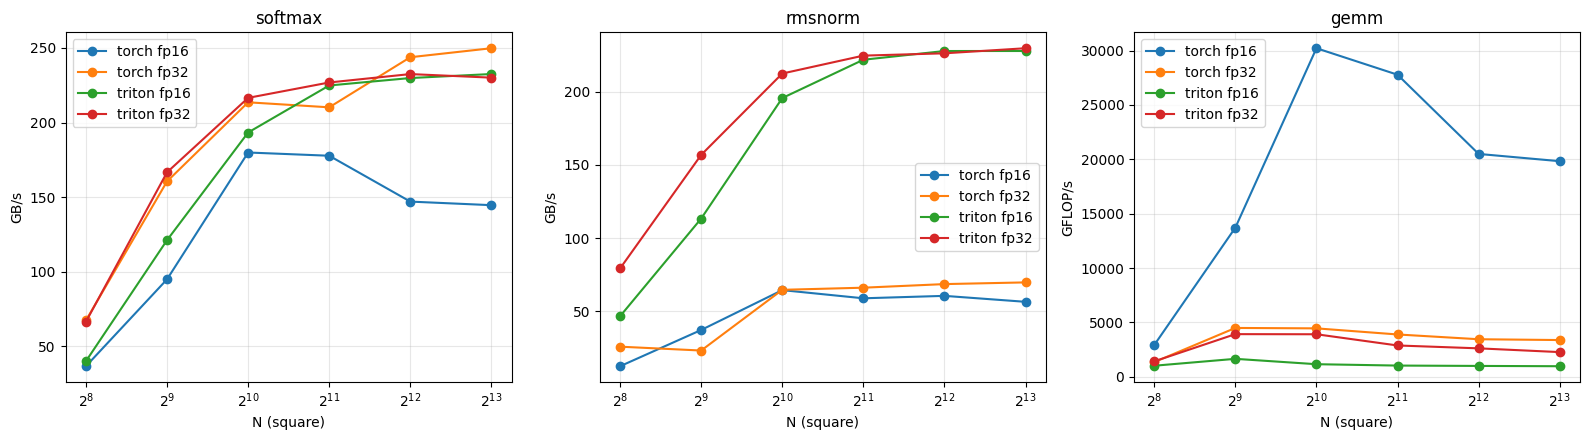

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

fp32 = pd.read_csv("results_t4_fp32.csv"); fp32["dtype"] = "fp32"
fp16 = pd.read_csv("results_t4_fp16.csv"); fp16["dtype"] = "fp16"
df = pd.concat([fp32, fp16])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, kernel in zip(axes, ["softmax", "rmsnorm", "gemm"]):
    sub = df[df.kernel == kernel]
    for (impl, dtype), g in sub.groupby(["impl", "dtype"]):
        g = g.sort_values("size")
        bytes_per = 4 if dtype == "fp32" else 2
        if kernel == "gemm":
            yvals = 2 * g["size"]**3 / (g["ms"] * 1e-3) / 1e9
            ylabel = "GFLOP/s"
        else:
            yvals = 2 * g["size"]**2 * bytes_per / (g["ms"] * 1e-3) / 1e9
            ylabel = "GB/s"
        ax.plot(g["size"], yvals, marker="o", label=f"{impl} {dtype}")
    ax.set_title(kernel); ax.set_xlabel("N (square)"); ax.set_ylabel(ylabel)
    ax.set_xscale("log", base=2); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("t4_perf.png", dpi=150)
plt.show()

In [33]:
from google.colab import files
files.download("results_t4_fp16.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files
files.download("friction-log.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>